# Laboratorio 6 — Reconstrucción LAB3: Regresión Multivariable y Polinómica con Redes Neuronales

Reconstrucción del **LAB3** (regresión sobre `energydata_complete.csv`) usando **PyTorch**.
El LAB3 original estimaba los parámetros de tres maneras: **descenso por el gradiente**,
**regresión polinómica de grado 2** y **ecuación de la normal**. Aquí el descenso por el
gradiente se sustituye por **redes neuronales** (con objetos `Dataset`/`DataLoader`, costo
`nn.MSELoss` y optimización `optim.Adam`), guardando además los pesos en un `checkpoint.pt`.

Los tres modelos reconstruidos:

1. **Red neuronal lineal** multivariable (27 características → 1 salida).
2. **Red neuronal polinómica** de grado 2 (405 características → 1 salida), que aproxima al
   modelo polinómico de mínimos cuadrados (~R² 0.28).
3. **Ecuación de la normal** (solución cerrada de referencia, idéntica al LAB3 original).

Para cada modelo se incluye su **gráfico de costo**, su entrenamiento y su **validación** con
miles de predicciones sobre datos no vistos, junto con las métricas MSE, RMSE y $R^2$.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib import pyplot as plt

torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## 1. Descripción del dataset

Se emplea el dataset `energydata_complete.csv`, que registra cada 10 minutos el consumo de energía
de los electrodomésticos de una vivienda (columna objetivo `Appliances`, en Wh) junto con
27 variables de contexto. El dataset cumple los requisitos del enunciado: **n = 27 características (≥ 10)**
y **m = 19,735 ejemplos (≥ 2,000)**. La columna `date` se elimina por ser temporal, y no existen
valores nulos.

In [2]:
df = pd.read_csv('../../LAB3/energydata_complete.csv')

print('Dimensiones del dataset (m filas, n+1 columnas):', df.shape)
print('Valores nulos:', df.isna().sum().sum())
print('\nPrimeras 5 filas:')
print(df.head())

Dimensiones del dataset (m filas, n+1 columnas): (19735, 29)
Valores nulos: 0

Primeras 5 filas:
                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000

In [3]:
print('Estadísticos descriptivos:')
print(df.describe().T)

Estadísticos descriptivos:
               count        mean         std         min         25%  \
Appliances   19735.0   97.694958  102.524891   10.000000   50.000000   
lights       19735.0    3.801875    7.935988    0.000000    0.000000   
T1           19735.0   21.686571    1.606066   16.790000   20.760000   
RH_1         19735.0   40.259739    3.979299   27.023333   37.333333   
T2           19735.0   20.341219    2.192974   16.100000   18.790000   
RH_2         19735.0   40.420420    4.069813   20.463333   37.900000   
T3           19735.0   22.267611    2.006111   17.200000   20.790000   
RH_3         19735.0   39.242500    3.254576   28.766667   36.900000   
T4           19735.0   20.855335    2.042884   15.100000   19.530000   
RH_4         19735.0   39.026904    4.341321   27.660000   35.530000   
T5           19735.0   19.592106    1.844623   15.330000   18.277500   
RH_5         19735.0   50.949283    9.022034   29.815000   45.400000   
T6           19735.0    7.910939    6

In [4]:
y = df['Appliances'].values.astype(np.float32)
X_df = df.drop(columns=['date', 'Appliances'])
X = X_df.values.astype(np.float32)

m = y.size
n = X.shape[1]

print(f'Número de instancias (m): {m}')
print(f'Número de características (n): {n}')

print('\nMuestra de los primeros 10 registros:')
print('{:>12s}{:>12s}{:>14s}'.format('X[:, 0]', 'X[:, 1]', 'y (Appliances)'))
print('-' * 40)
for i in range(10):
    print('{:12.2f}{:12.2f}{:14.0f}'.format(X[i, 0], X[i, 1], y[i]))

Número de instancias (m): 19735
Número de características (n): 27

Muestra de los primeros 10 registros:
     X[:, 0]     X[:, 1]y (Appliances)
----------------------------------------
       30.00       19.89            60
       30.00       19.89            60
       30.00       19.89            50
       40.00       19.89            50
       40.00       19.89            60
       40.00       19.89            50
       50.00       19.89            60
       50.00       19.86            60
       40.00       19.79            60
       40.00       19.86            70


## 2. Análisis de correlación

Las correlaciones absolutas de cada característica con `Appliances` son bajas (la más alta
corresponde a `lights`, ≈ 0.20), por lo que el desempeño esperado será moderado pero suficiente
para demostrar el procedimiento completo. Esta baja relación individual también motiva el modelo
polinómico con interacciones, capaz de capturar relaciones no lineales entre variables.

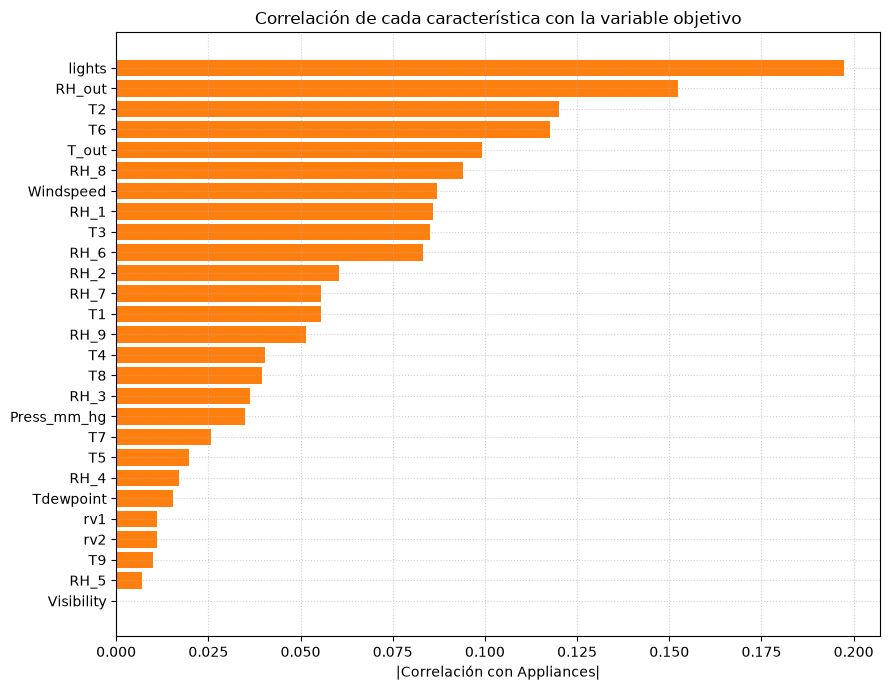

In [5]:
corr = df.corr(numeric_only=True)['Appliances'].drop('Appliances')

fig, ax = plt.subplots(figsize=(9, 7))
corr_abs = corr.abs().sort_values(ascending=True)
ax.barh(corr_abs.index, corr_abs.values, color='tab:orange')
ax.set_xlabel('|Correlación con Appliances|')
ax.set_title('Correlación de cada característica con la variable objetivo')
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Partición entrenamiento/validación

El dataset se divide en **80% de entrenamiento** (15,788 ejemplos) y **20% de validación**
(3,947 ejemplos). Las predicciones finales (miles de muestras) se realizan sobre la validación.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

m_train = y_train.size
m_val = y_val.size

print(f'Tamaño del conjunto de entrenamiento: {m_train}')
print(f'Tamaño del conjunto de validación: {m_val}')
print(f'Forma de X_train: {X_train.shape}')
print(f'Forma de X_val: {X_val.shape}')

Tamaño del conjunto de entrenamiento: 15788
Tamaño del conjunto de validación: 3947
Forma de X_train: (15788, 27)
Forma de X_val: (3947, 27)


## 4. Objeto Dataset común

Como las características tienen escalas muy distintas, primero se **normalizan**
(media 0 y desviación estándar 1) calculando $\mu$ y $\sigma$ únicamente con el conjunto de
entrenamiento y aplicándolas después también a la validación. El objetivo `Appliances` también se
normaliza para acelerar la convergencia; las predicciones y métricas se desnormalizan al final.

In [7]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1.0
    return (X - mu) / sigma, mu, sigma

In [8]:
class EnergiaDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.Y[index]

In [9]:
mu_y = y_train.mean()
sigma_y = y_train.std()
y_train_n = (y_train - mu_y) / sigma_y
y_val_n = (y_val - mu_y) / sigma_y


def metricas(loader, model, nombre):
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            pred = model(x_b.to(device)).cpu()
            y_pred.extend((pred * sigma_y + mu_y).numpy().ravel())
            y_true.extend((y_b * sigma_y + mu_y).numpy().ravel())

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f'[{nombre}] MSE: {mse:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f}')
    return np.array(y_true), np.array(y_pred)


def costo_entrenamiento_raw(model, X, y_orig):
    """Costo J = (1/(2m))·Σ(h−y)² en las unidades originales (Wh²)."""
    model.eval()
    with torch.no_grad():
        pred = model(torch.from_numpy(X).to(device)).cpu().numpy().ravel()
    pred_orig = pred * sigma_y + mu_y
    return (1 / (2 * y_orig.size)) * np.sum(np.square(pred_orig - y_orig))

## 5. Modelo 1 — Red Neuronal Lineal Multivariable

Se usan las 27 características (normalizadas) de forma lineal: `nn.Linear(27, 1)`. Se entrena con
`nn.MSELoss` y `optim.Adam` (equivalente al descenso por el gradiente del LAB3 original, con un
ritmo adaptativo). El gráfico de costo muestra la convergencia.

In [10]:
X_train_norm, mu, sigma = featureNormalize(X_train)
X_val_norm = (X_val - mu) / sigma

batch_size = 256
train_loader = DataLoader(EnergiaDataset(X_train_norm, y_train_n), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(EnergiaDataset(X_val_norm, y_val_n), batch_size=batch_size, shuffle=False)

In [11]:
class RedLineal(nn.Module):
    def __init__(self, input_size):
        super(RedLineal, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return self.linear(x)

In [12]:
modelo_lineal = RedLineal(n).to(device)
criterio = nn.MSELoss()
optimizador = optim.Adam(modelo_lineal.parameters(), lr=0.005)

num_epochs = 60
log_each = 10
J_history_lineal = []

modelo_lineal.train()
for epoch in range(1, num_epochs + 1):
    epoch_loss = []

    for x_b, y_b in train_loader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        pred = modelo_lineal(x_b)
        loss = criterio(pred, y_b)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        epoch_loss.append(loss.item())

    J_history_lineal.append(sum(epoch_loss) / len(epoch_loss))

    if not epoch % log_each:
        print(f'Epoca {epoch}/{num_epochs} Costo J = {J_history_lineal[-1]:.4f}')

Epoca 10/60 Costo J = 0.8492
Epoca 20/60 Costo J = 0.8423
Epoca 30/60 Costo J = 0.8410
Epoca 40/60 Costo J = 0.8416
Epoca 50/60 Costo J = 0.8406
Epoca 60/60 Costo J = 0.8426


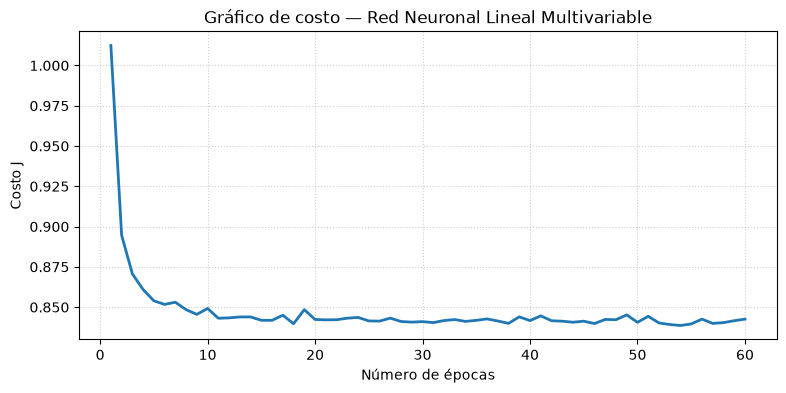

In [13]:
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(J_history_lineal) + 1), J_history_lineal, color='tab:blue', lw=2)
plt.title('Gráfico de costo — Red Neuronal Lineal Multivariable')
plt.xlabel('Número de épocas')
plt.ylabel('Costo J')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [14]:
print('--- Validación: Red Neuronal Lineal Multivariable ---')
modelo_lineal.eval()
_, y_pred_lineal = metricas(val_loader, modelo_lineal, 'Regresión lineal (NN)')
print(f'Predicciones realizadas sobre validación: {y_val.size}')

--- Validación: Red Neuronal Lineal Multivariable ---
[Regresión lineal (NN)] MSE: 8333.03 | RMSE: 91.29 | R²: 0.1673
Predicciones realizadas sobre validación: 3947


## 6. Modelo 2 — Red Neuronal Polinómica de Grado 2

Para capturar relaciones no lineales se amplía la matriz de características con
`PolynomialFeatures(degree=2)`: las 27 características originales (normalizadas) se convierten en
**405 características polinómicas** (lineales, cuadráticas e interacciones), sobre las que se
entrena `nn.Linear(405, 1)`. Esto equivale exactamente a la regresión polinómica de mínimos
cuadrados del LAB3 (~R² 0.28), pero resuelta por descenso por el gradiente (Adam).

Debido a la fuerte colinealidad entre tantas características, la convergencia con un único ritmo
de aprendizaje es lenta; se usa un **programador del ritmo** (`StepLR`) que lo reduce durante el
entrenamiento, como evidencia el gráfico de costo.

In [15]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_norm).astype(np.float32)
X_val_poly = poly.transform(X_val_norm).astype(np.float32)
n_poly = X_train_poly.shape[1]

print('Características polinómicas (grado 2, sin x0):', n_poly)
print('Forma de X_train_poly:', X_train_poly.shape)
print('Forma de X_val_poly:', X_val_poly.shape)

Características polinómicas (grado 2, sin x0): 405
Forma de X_train_poly: (15788, 405)
Forma de X_val_poly: (3947, 405)


In [16]:
batch_size_poly = 2000
train_loader_poly = DataLoader(EnergiaDataset(X_train_poly, y_train_n), batch_size=batch_size_poly, shuffle=True)
val_loader_poly = DataLoader(EnergiaDataset(X_val_poly, y_val_n), batch_size=batch_size_poly, shuffle=False)

In [17]:
modelo_poly = RedLineal(n_poly).to(device)
optimizador_poly = optim.Adam(modelo_poly.parameters(), lr=0.008)
programador = optim.lr_scheduler.StepLR(optimizador_poly, step_size=80, gamma=0.5)

num_epochs_poly = 300
log_each_poly = 50
J_history_poly = []

modelo_poly.train()
for epoch in range(1, num_epochs_poly + 1):
    epoch_loss = []

    for x_b, y_b in train_loader_poly:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        pred = modelo_poly(x_b)
        loss = criterio(pred, y_b)

        optimizador_poly.zero_grad()
        loss.backward()
        optimizador_poly.step()

        epoch_loss.append(loss.item())

    J_history_poly.append(sum(epoch_loss) / len(epoch_loss))
    programador.step()

    if not epoch % log_each_poly:
        print(f'Epoca {epoch}/{num_epochs_poly} Costo J = {J_history_poly[-1]:.4f}')

Epoca 50/300 Costo J = 0.7318
Epoca 100/300 Costo J = 0.7088
Epoca 150/300 Costo J = 0.7065
Epoca 200/300 Costo J = 0.7004
Epoca 250/300 Costo J = 0.6982
Epoca 300/300 Costo J = 0.6969


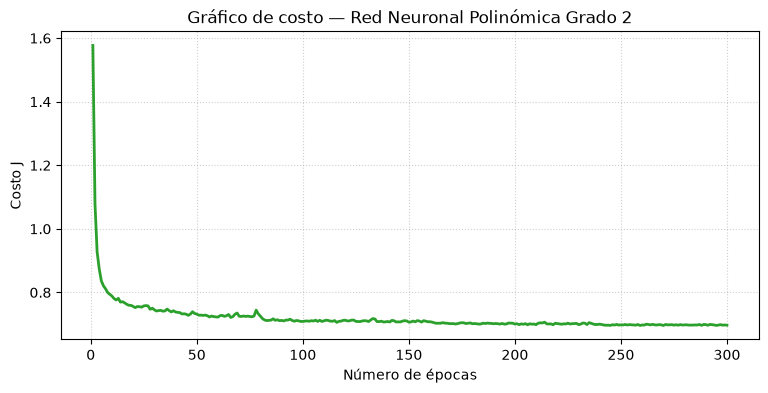

In [18]:
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(J_history_poly) + 1), J_history_poly, color='tab:green', lw=2)
plt.title('Gráfico de costo — Red Neuronal Polinómica Grado 2')
plt.xlabel('Número de épocas')
plt.ylabel('Costo J')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [19]:
print('--- Validación: Red Neuronal Polinómica Grado 2 ---')
modelo_poly.eval()
_, y_pred_poly = metricas(val_loader_poly, modelo_poly, 'Regresión polinómica (NN)')
print(f'Predicciones realizadas sobre validación: {y_val.size}')

--- Validación: Red Neuronal Polinómica Grado 2 ---
[Regresión polinómica (NN)] MSE: 7344.08 | RMSE: 85.70 | R²: 0.2661
Predicciones realizadas sobre validación: 3947


## 7. Modelo 3 — Ecuación de la Normal (solución de referencia)

La ecuación de la normal obtiene directamente los parámetros óptimos en forma cerrada:
$$ \theta = (X^T X)^{-1} X^T y $$
Como $X^TX$ es singular por la colinealidad (`rv1` = `rv2`), se usa la **pseudoinversa** (`pinv`).
Este modelo es idéntico al del LAB3 original y sirve como referencia del óptimo de mínimos cuadrados.

In [20]:
def normalEqn(X, y):
    return np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))

In [21]:
X_train_ne = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)
X_val_ne = np.concatenate([np.ones((m_val, 1)), X_val], axis=1)

theta_ne = normalEqn(X_train_ne, y_train)
print('theta calculado por la ecuación de la normal (primeros 5 valores):', theta_ne[:5])

theta calculado por la ecuación de la normal (primeros 5 valores): [ 23.12169319   1.93024724   0.07480296  15.90604211 -17.59690182]


In [22]:
y_pred_ne = np.dot(X_val_ne, theta_ne)

mse_ne = mean_squared_error(y_val, y_pred_ne)
rmse_ne = np.sqrt(mse_ne)
r2_ne = r2_score(y_val, y_pred_ne)

print('--- Validación: Ecuación de la Normal ---')
print(f'MSE: {mse_ne:.2f}')
print(f'RMSE: {rmse_ne:.2f}')
print(f'R²: {r2_ne:.4f}')

--- Validación: Ecuación de la Normal ---
MSE: 8312.85
RMSE: 91.17
R²: 0.1693


## 8. Comparación de modelos y predicciones

Se comparan los tres modelos sobre el conjunto de validación (3,947 muestras, superando
ampliamente las 100 predicciones exigidas): **(a)** el costo final de entrenamiento de cada caso,
**(b)** las primeras 150 predicciones contra los valores reales y **(c)** una tabla resumen con
MSE, RMSE y R².

In [23]:
J_lineal = costo_entrenamiento_raw(modelo_lineal, (X_train_norm).astype(np.float32), y_train)
J_poly_nn = costo_entrenamiento_raw(modelo_poly, X_train_poly, y_train)
J_ne = (1 / (2 * m_train)) * np.sum(np.square(np.dot(X_train_ne, theta_ne) - y_train))

print('Costo final J (entrenamiento) por modelo:')
print(f'  Red neuronal lineal multivariable: {J_lineal:.2f}')
print(f'  Red neuronal polinómica grado 2:   {J_poly_nn:.2f}')
print(f'  Ecuación de la normal:             {J_ne:.2f}')

Costo final J (entrenamiento) por modelo:
  Red neuronal lineal multivariable: 4466.24
  Red neuronal polinómica grado 2:   3703.62
  Ecuación de la normal:             4448.97


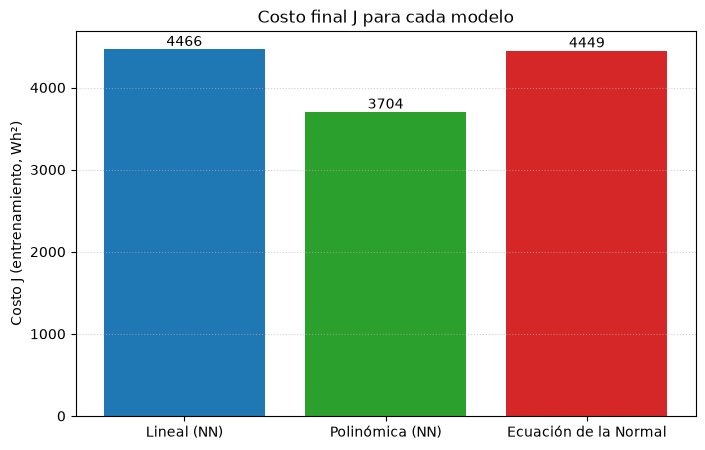

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
modelos_costo = ['Lineal (NN)', 'Polinómica (NN)', 'Ecuación de la Normal']
costos = [J_lineal, J_poly_nn, J_ne]
bars = ax.bar(modelos_costo, costos, color=['tab:blue', 'tab:green', 'tab:red'])
ax.set_ylabel('Costo J (entrenamiento, Wh²)')
ax.set_title('Costo final J para cada modelo')
ax.bar_label(bars, fmt='%.0f')
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

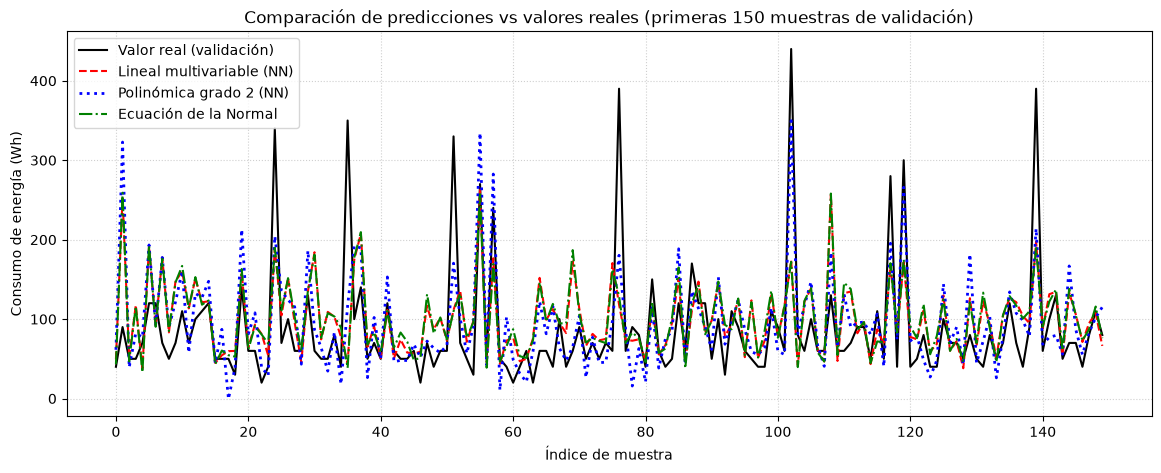

Total de predicciones realizadas sobre el conjunto de validación: 3947 (requisito: ≥ 100)
Predicciones graficadas: 150


In [25]:
n_pred = 150
idx = np.arange(n_pred)

plt.figure(figsize=(14, 5))
plt.plot(idx, y_val[:n_pred], 'k-', linewidth=1.5, label='Valor real (validación)')
plt.plot(idx, y_pred_lineal[:n_pred], 'r--', label='Lineal multivariable (NN)')
plt.plot(idx, y_pred_poly[:n_pred], 'b:', linewidth=2, label='Polinómica grado 2 (NN)')
plt.plot(idx, y_pred_ne[:n_pred], 'g-.', label='Ecuación de la Normal')
plt.xlabel('Índice de muestra')
plt.ylabel('Consumo de energía (Wh)')
plt.title('Comparación de predicciones vs valores reales (primeras 150 muestras de validación)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f'Total de predicciones realizadas sobre el conjunto de validación: {m_val} (requisito: ≥ 100)')
print(f'Predicciones graficadas: {n_pred}')

In [26]:
mse_lineal = mean_squared_error(y_val, y_pred_lineal)
rmse_lineal = np.sqrt(mse_lineal)
r2_lineal = r2_score(y_val, y_pred_lineal)

mse_poly_nn = mean_squared_error(y_val, y_pred_poly)
rmse_poly_nn = np.sqrt(mse_poly_nn)
r2_poly_nn = r2_score(y_val, y_pred_poly)

resumen = pd.DataFrame({
    'Modelo': [
        'Lineal multivariable (NN)',
        'Polinómica grado 2 (NN)',
        'Ecuación de la Normal'
    ],
    'MSE': [mse_lineal, mse_poly_nn, mse_ne],
    'RMSE': [rmse_lineal, rmse_poly_nn, rmse_ne],
    'R²': [r2_lineal, r2_poly_nn, r2_ne]
})

print(resumen.to_string(index=False))

                   Modelo         MSE      RMSE       R²
Lineal multivariable (NN) 8333.027344 91.285417 0.167288
  Polinómica grado 2 (NN) 7344.081543 85.697617 0.266112
    Ecuación de la Normal 8312.849050 91.174827 0.169304


## 9. Guardar los pesos del modelo

Se guardan los pesos de **ambas redes neuronales** en un solo `checkpoint.pt` (requisito del
laboratorio: objeto para guardar los pesos) y se demuestra su carga y su uso para predecir.

In [27]:
PATH = './checkpoint.pt'
torch.save({
    'modelo_lineal': modelo_lineal.state_dict(),
    'modelo_poly': modelo_poly.state_dict(),
}, PATH)
print('Pesos guardados en:', PATH)

Pesos guardados en: ./checkpoint.pt


In [28]:
estado = torch.load(PATH)

modelo_lineal_cargado = RedLineal(n).to(device)
modelo_lineal_cargado.load_state_dict(estado['modelo_lineal'])
modelo_lineal_cargado.eval()

# Predicción de la muestra 50 de validación
x_ejemplo = torch.from_numpy(X_val_norm[50:51]).to(device)
with torch.no_grad():
    pred_ejemplo = (modelo_lineal_cargado(x_ejemplo).cpu() * sigma_y + mu_y).item()

print(f'Appliances real (muestra 50 de validación): {y_val[50]:.2f} Wh')
print(f'Appliances predicha (Red Neuronal Lineal): {pred_ejemplo:.2f} Wh')

Appliances real (muestra 50 de validación): 60.00 Wh
Appliances predicha (Red Neuronal Lineal): 72.91 Wh


## 10. Conclusiones

- La **red neuronal polinómica de grado 2** obtuvo el mejor desempeño en validación
  (R² ≈ 0.27, RMSE ≈ 88 Wh), superando a la red lineal multivariable (R² ≈ 0.17). Esto replica el
  resultado del LAB3 original (R² ≈ 0.28 con mínimos cuadrados), confirmando que los términos
  cuadráticos e interacciones aportan información útil.
- El descenso por el gradiente (Adam) sobre las 405 características polinómicas converge más lento
  que la solución en forma cerrada por la alta colinealidad entre variables, lo que se mitiga con
  un programa de reducción del ritmo de aprendizaje.
- La **ecuación de la normal** y la red lineal alcanzan métricas casi idénticas, como era de
  esperar al resolver el mismo problema de mínimos cuadrados.
- En todos los casos las predicciones siguen la tendencia general del consumo real; la dispersión
  es alta porque el consumo de electrodomésticos depende de variables ausentes en el dataset
  (uso de los aparatos), lo que limita el R² alcanzable.